## Calculate WD luminosity function from the model

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from jjmodel.input_ import p, a, inp
from jjmodel.mwdisk import local_run
from helpers import (PopHandler, SFRHandler, IMFHandler, 
                     ParHandler, MSAgeHandler, IFMRHandler, extract_model_tables)

from prior import prior


Parameter file(s) : ok.
Number of parameters =  66 , among them technical =  7

 p(run_mode=0, out_dir='new_metgrid', out_mode=1, nprocess=4, Rsun=8.275, zsun=20, zmax=2000, dz=5, sigmad=29.3, sigmat=4.9, sigmag1=2.0, sigmag2=11.0, sigmadh=51.9, sigmash=0.47, td1=0, td2=7.8, dzeta=0.8, eta=5.6, pkey=1, tt1=0.1, tt2=4, gamma=2, beta=3.5, imfkey=0, a0=1.31, a1=1.5, a2=2.88, a3=2.28, m0=0.49, m1=1.43, m2=6.0, dFeHdt=0, n_FeHdt=1, fehkey=0, FeHd0=-0.7, FeHdp=0.29, rd=0.34, q=-0.72, FeHt0=-0.94, FeHtp=0.04, rt=0.77, t0=0.97, FeHsh=-1.5, dFeHsh=0.4, n_FeHsh=5, alpha=0.375, sige=26.0, sigt=45, sigdh=140, sigsh=100, sigmap=array([3.5, 1.3]), tpk=array([10. , 12.5]), dtp=array([0.7 , 0.25]), sigp=array([26.3, 12.6]))

Parameters checked: 0 Reminders, 0 Warnings, 0 Errors.

Configuration finished:  0h 0m 0.0s


In [2]:
# As usually, define some parameters

mag_range = [[-0.5,1.65],[-5,18.5]] # col-mag range, same everywhere
mag_step = [0.02,0.2]               # col-mag step, same everywhere

# Create color-absmag grid (bin centers)
x = np.arange(mag_range[0][0] + mag_step[0]/2,mag_range[0][1] + mag_step[0]/2,mag_step[0])
y = np.arange(mag_range[1][0] + mag_step[1]/2,mag_range[1][1] + mag_step[1]/2,mag_step[1])

# And the grid with absmag bin adges
bins = np.arange(mag_range[1][0],mag_range[1][1] + mag_step[1],mag_step[1])

f_da_teff = False    # If True fraction of DA/DB WDs is a function of Teff
# Parameters for MS lifetime fits
age_ms_param_file =\
    'MS_lifetime_padova_new_metgrid/analysis/fit_v1_Mbr1.18/tau_ms_params_v1_Mbr1.18.txt'

In [ ]:
# Generate populations 

labels = ['d','t','sh']

imf_handler = IMFHandler(p)
ifmr_handler = IFMRHandler(a)
sfr_handler = SFRHandler(p, a, inp)
pop_handler = PopHandler(p, a, inp)
msage_handler = MSAgeHandler(param_file=age_ms_param_file)
                                          
SFR_ref = sfr_handler.create_reference_sfr()
imf_ref, (mass_binsc, IMF_ref) = imf_handler.create_reference_imf()

# Create population tables
pop_kwargs = {'FeH_scatter':0.07,'Nmet_dt':7,'wd':'ms+wd'}
pop_tabs_ref = pop_handler.create_reference_pop_tabs(imf_ref, 'Padova', **pop_kwargs)
pop_tabs_ref = pop_handler.create_reference_columns(pop_tabs_ref,['N', 'Mini', 'age', 'age_WD'])
indt, indm = pop_handler.get_age_mass_idx(pop_tabs_ref,mass_binsc)

# Define DA/DB WD indices
ind_wd = pop_handler.make_wd_idx_dict(pop_tabs_ref)
idx_wd, idx_ms = pop_handler.separate_wd_ms_idx(pop_tabs_ref,ind_wd)
idx_pop = pop_handler.split_into_pops(pop_tabs_ref)
idx_pop_combined = pop_handler.combine_pops_indices(pop_tabs_ref,idx_pop)

# Read volume completeness data
d_mg_lim = np.loadtxt('./completeness/gdr3_dlim_vs_MG.txt').T
vz_grid = np.loadtxt('./completeness/vz_grid_myvolume.txt').T
vz_mag = pop_handler.get_vz_mag(pop_tabs_ref, d_mg_lim, vz_grid)


Stellar population synthesis for R = 8.275 kpc:
Warning. Some of modeled metallicities (halo) are outside of Padova metallicity range [-2.2,0.5], i.e., the adopted best isochrones may be not representative.
	thin disk	thick disk	halo


In [ ]:
# Choose parameters to be updated
# ------------------------------------------
par_optim = {
    'ifmr':         ['alpha1','alpha2','alpha3'],
    'dcool':        ['alpha_cool'],
    'f_dadb':       ['f_da'],
    'sfr': {'d':    ['dzeta','eta','sigmad','sigmap0','tpk0']},
    'imf':          ['a0', 'a1', 'a2']
}

par_handler = ParHandler(par_optim,prior)
_ = par_handler.get_flat_param_list()
params_mean, params_sigma = par_handler.get_prior_for_params()

#params = params_mean # use this line for the default model
#params = [0.119, 0.177, 0.088, 0.08, 0.779, 0.72, 5.516, 29.47, 
#          3.419, 10.617, 1.318, 12.504, 0.913, 1.709, 2.804] # pop4
params = [ 0.117,  0.049,  0.102,  0.075,  0.775,  0.751,  5.693, 28.858,
        3.393, 10.602,  0.921,  1.708,  2.852] # mcmc_pop5

param_struct = par_handler.fill_param_struct(params)

kwargs_post = par_handler.prepare_posterior_kwargs(
    SFR_ref,
    IMF_ref,
    indt,
    indm,
    mode_pop='tot',
    ind_wd=ind_wd,
    ind_pop=idx_pop_combined, 
    f_da_teff=f_da_teff,
    ifmr_handler=ifmr_handler,
    msage_handler=msage_handler
)

if 'sfr' in param_struct.keys():
    inp, SFR_new = sfr_handler.update_sfr(**param_struct['sfr'])
    kwargs_post['SFR_new'] = SFR_new
    #print('Updated SFR')

if 'imf' in param_struct.keys():
    _, (_, IMF_new) = imf_handler.update_imf(**param_struct['imf'])
    kwargs_post['IMF_new'] = IMF_new
    #print('Updated IMF')

# Run the local model
out = local_run(p,a,inp,save=False,status_progress=False)
inp_tabs = extract_model_tables(out,inp)

# And update tables
pop_tabs, indt = pop_handler.update_pop_tabs(param_struct,pop_tabs_ref,**kwargs_post)

In [ ]:

# For default model (if you used params = params_mean in the previous cell)
# Read scale height tables and table with SFR peaks contributions
'''
Hd = np.loadtxt(os.path.join(a.T['heighttab'],'H_d_R' + str(p.Rsun) + '.txt')).T[1]
Hdp = np.loadtxt(os.path.join(a.T['heighttab'],'H_dp_R' + str(p.Rsun) + '.txt')).T[1]
Ht = np.loadtxt(os.path.join(a.T['heighttab'],'H_t_R' + str(p.Rsun) + '.txt')).T[1]
Hsh = np.loadtxt(os.path.join(a.T['heighttab'],'H_sh_R' + str(p.Rsun) + '.txt')).T[1]
Fp0 = np.loadtxt(os.path.join(a.T['inptab'],'F_dp_R' + str(p.Rsun) + '.txt')).T[1:]
''';

# For new model
Hd = inp_tabs['Hd']
Hdp = inp_tabs['Hdp']
Ht = inp_tabs['Ht']
Hsh = inp_tabs['Hsh']
Fp0 = inp_tabs['Fp']


In [6]:
# Calculate spatial number density for the chosen model

labels = ['d','t','sh']
N_v = {mode:[] for mode in labels}

for mode in labels:
    #tab = pop_tabs_ref[mode]
    tab = pop_tabs[mode]
    if mode == 'd':
        #indt_d = np.array(np.subtract(13,tab['age'])//0.025,dtype=int)
        indt_d=indt['d']
        nv0 = tab['N']/2/Hd[indt_d]*(1 - Fp0[0][indt_d] - Fp0[1][indt_d]) # main
        nv_p0 = tab['N']/2/Hdp[0]*Fp0[0][indt_d] # peak 1
        nv_p1 = tab['N']/2/Hdp[1]*Fp0[1][indt_d] # peak 2
        nv = nv0 + nv_p0 + nv_p1 # totaltab = pop_tabs[mode]
    elif mode == 't':
        nv = tab['N']/2/Ht
    elif mode == 'sh':
        nv = tab['N']/2/Hsh
    
    N_v[mode] = nv

In [ ]:
# Select WD and stack d-t-sh MG and NV 

ind_wd = pop_handler.make_wd_idx_dict(pop_tabs_ref)
ind_wd_dab = {mode:np.concatenate((ind_wd[mode][0],ind_wd[mode][1])) for mode in labels}

M_G_wd = np.concatenate(
    (pop_tabs_ref['d']['G_EDR3'][ind_wd_dab['d']],
    pop_tabs_ref['t']['G_EDR3'][ind_wd_dab['t']],
    pop_tabs_ref['sh']['G_EDR3'][ind_wd_dab['sh']])
    )
N_v_wd = np.concatenate(
    (N_v['d'][ind_wd_dab['d']],
    N_v['t'][ind_wd_dab['t']],
    N_v['sh'][ind_wd_dab['sh']])
)

In [ ]:
# Calculate WDLF from model

wdlf_m = np.histogram(M_G_wd,bins=bins,weights=N_v_wd)[0]
np.savetxt('./output/WDLF/wdlf_pop5.txt',np.stack((y,wdlf_m)),header='M_G, WDLF')

In [ ]:
# Get WDLF from data

# 1. Large volume
#--------------------------------

df = pd.read_parquet('./data/1kpc/source/1kpc_s0.parquet')

# Select WDs
df_wd = df[df['M_G0_lallement'] > 6*df['G_RP0_lallement_sm'] + 9.8]

n_wd = len(df_wd['M_G0_lallement'])

# Find index of mag bin for each star
ind_mag = np.array((df_wd['M_G0_lallement'] - d_mg_lim[0][0])//mag_step[1],dtype=int)

# Extract distance limits for magnitude grid 
# Cut at 1 kpc as we don't model beyond that
d_low_bins = [int(d) if d <= 1000 else 1000 for d in d_mg_lim[2]]
d_up_bins = [int(d) if d <= 1000 else 1000 for d in d_mg_lim[3]]

ind_dlim_mag = np.zeros((n_wd,2),dtype=int)
ind_dlim_mag[:,0] = np.array(d_low_bins, dtype=int)[ind_mag]
ind_dlim_mag[:,1] = np.array(d_up_bins, dtype=int)[ind_mag]

# Add a column with zeros to use lmiting distances as indices 
# (vz grid was calculed for d from 1 pc, not from 0). 
vz_grid = np.concatenate((np.zeros((1,vz_grid.shape[1])), vz_grid), axis=0)

# Calculate volume for each MW component and each population
w = np.zeros((n_wd)) 
vz_mag = np.zeros((n_wd, vz_grid.shape[1]))

for i in range(n_wd):
    # Subtract volume at d_min (inner hole due to bright limit)
    vz_mag[i,:] = vz_grid[ind_dlim_mag[i,1],:] - vz_grid[ind_dlim_mag[i,0],:]
    # contribution of each star is 1/total_volume, total_volume is a sum over all z
    w[i] = 1/vz_mag[i,:].sum()

# Calculate WDLF
wdlf_d = np.histogram(df_wd['M_G0_lallement'],bins=bins,weights=w)[0]
wdlf_ed = np.histogram(df_wd['M_G0_lallement'],bins=bins,weights=w**2)[0]
wdlf_ed = np.sqrt(wdlf_ed)

np.savetxt('./output/WDLF/wdlf_myvolume_data.txt',np.stack((y,wdlf_d,wdlf_ed)),
           header='M_G, WDLF, e_WDLF')

In [ ]:
# 2. 50-pc sphere with clean WD sample
#----------------------------------------

df2 = pd.read_csv('./data/GCWD21+Golovin24_source_deblended_w.csv')
df_wd_50 = df2[df2['d'] < 50] # select 50 pc sphere
w_50 = np.array([3/4/np.pi/50**3 for _ in df_wd_50['d']]) # weights = 1/volume_sphere

# Calculate WDLF
wdlf_d_50 = np.histogram(df_wd_50['M_G'],bins=bins,weights=w_50)[0]
wdlf_ed_50 = np.histogram(df_wd_50['M_G'],bins=bins,weights=w_50**2)[0]
wdlf_ed_50 = np.sqrt(wdlf_ed_50)

np.savetxt('./output/WDLF/wdlf_50pc_data.txt',np.stack((y,wdlf_d_50,wdlf_ed_50)),
           header='M_G, WDLF, e_WDLF')

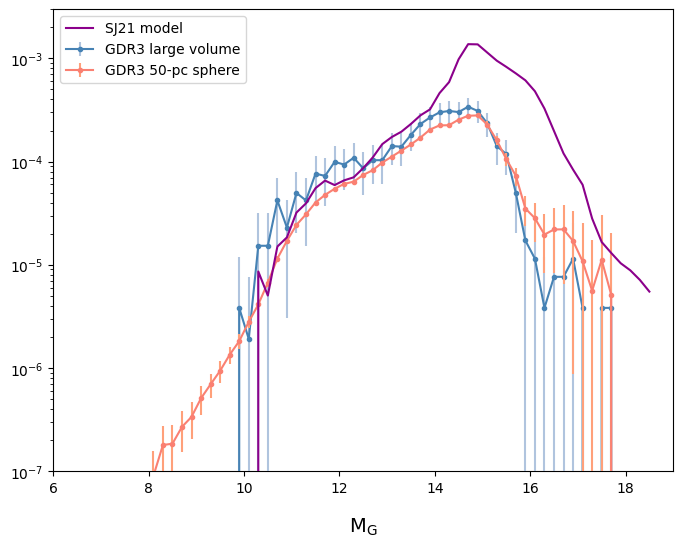

In [20]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.errorbar(y,wdlf_d_50,yerr=3*wdlf_ed_50,marker='o',markersize=3,
            c='steelblue',ecolor='lightsteelblue',label='GDR3 large volume',zorder=10)
ax.errorbar(y,wdlf_d,yerr=3*wdlf_ed,marker='o',markersize=3,
            c='salmon',ecolor='lightsalmon',label='GDR3 50-pc sphere',zorder=20)

ax.plot(y,wdlf_m,c='darkmagenta',label='SJ21 model',lw=1.5,zorder=30)

ax.set_yscale('log')
ax.set_xlim(6,19)
ax.set_ylim(1e-7,3e-3)
ax.set_xlabel(r'$\mathrm{M_G}$',labelpad=15,fontsize=14)
plt.legend(loc=2)
